# Confidence-Interval Solver Curves

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scienceplots

plt.style.use(["science", "nature"])

ROOT = Path.cwd().resolve()
DOWNLOADS = Path.home() / "Downloads"

diff_path = DOWNLOADS / "conf_interval_diff_curve_synthetic_amortized.csv"
timing_path = DOWNLOADS / "conf_interval_timing_curve_synthetic_amortized.csv"
output_path = "conf_interval_solver_curves_synthetic_amortized.pdf"

diff = pd.read_csv(diff_path)
timing = pd.read_csv(timing_path)

display(diff.head())
display(timing.head())

,num_intervened,abs_diff_mean,abs_diff_median,abs_diff_max,slsqp_objective_mean,slsqp_objective_max,slsqp_maha_mean,slsqp_maha_max,slsqp_maha_cutoff,slsqp_maha_violation_mean,...,slsqp_direction_violation_count,fw_objective_mean,fw_objective_max,fw_maha_mean,fw_maha_max,fw_maha_cutoff,fw_maha_violation_mean,fw_maha_violation_max,fw_direction_min,fw_direction_violation_count
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0
1,10,0.004555,0.003685,0.024143,2.678107,3.239244,23.209698,23.211117,23.209251,0.000448,...,0,2.678071,3.239214,23.209255,23.209259,23.209251,8.419156e-07,0.000008,0.645646,0
2,20,0.005925,0.004561,0.036503,5.998685,6.772194,37.568569,37.570236,37.566235,0.002335,...,0,5.998605,6.772007,37.566227,37.566246,37.566235,1.147389e-06,0.000011,0.361354,0
3,30,0.003228,0.002189,0.038451,9.468657,10.437375,50.895542,50.898167,50.892181,0.003362,...,0,9.468784,10.437509,50.892178,50.892193,50.892181,1.117587e-06,0.000011,0.291820,0
4,40,0.002097,0.001549,0.021718,13.044184,14.382458,63.693115,63.698708,63.690740,0.002376,...,0,13.044312,14.382891,63.690735,63.690758,63.690740,1.750886e-06,0.000019,0.110407,0


,num_intervened,fw_step_sec,fw_cumulative_sec,slsqp_step_sec,slsqp_cumulative_sec
0,0,0.000000,0.000000,0.000000,0.000000
1,10,0.108306,0.108306,1.090069,1.090069
2,20,0.084527,0.192834,1.126457,2.216526
3,30,0.061393,0.254227,1.315410,3.531936
4,40,0.129097,0.383324,1.458264,4.990200


In [2]:
diff.keys()

Index(['num_intervened', 'abs_diff_mean', 'abs_diff_median', 'abs_diff_max',
       'slsqp_objective_mean', 'slsqp_objective_max', 'slsqp_maha_mean',
       'slsqp_maha_max', 'slsqp_maha_cutoff', 'slsqp_maha_violation_mean',
       'slsqp_maha_violation_max', 'slsqp_direction_min',
       'slsqp_direction_violation_count', 'fw_objective_mean',
       'fw_objective_max', 'fw_maha_mean', 'fw_maha_max', 'fw_maha_cutoff',
       'fw_maha_violation_mean', 'fw_maha_violation_max', 'fw_direction_min',
       'fw_direction_violation_count'],
      dtype='object')

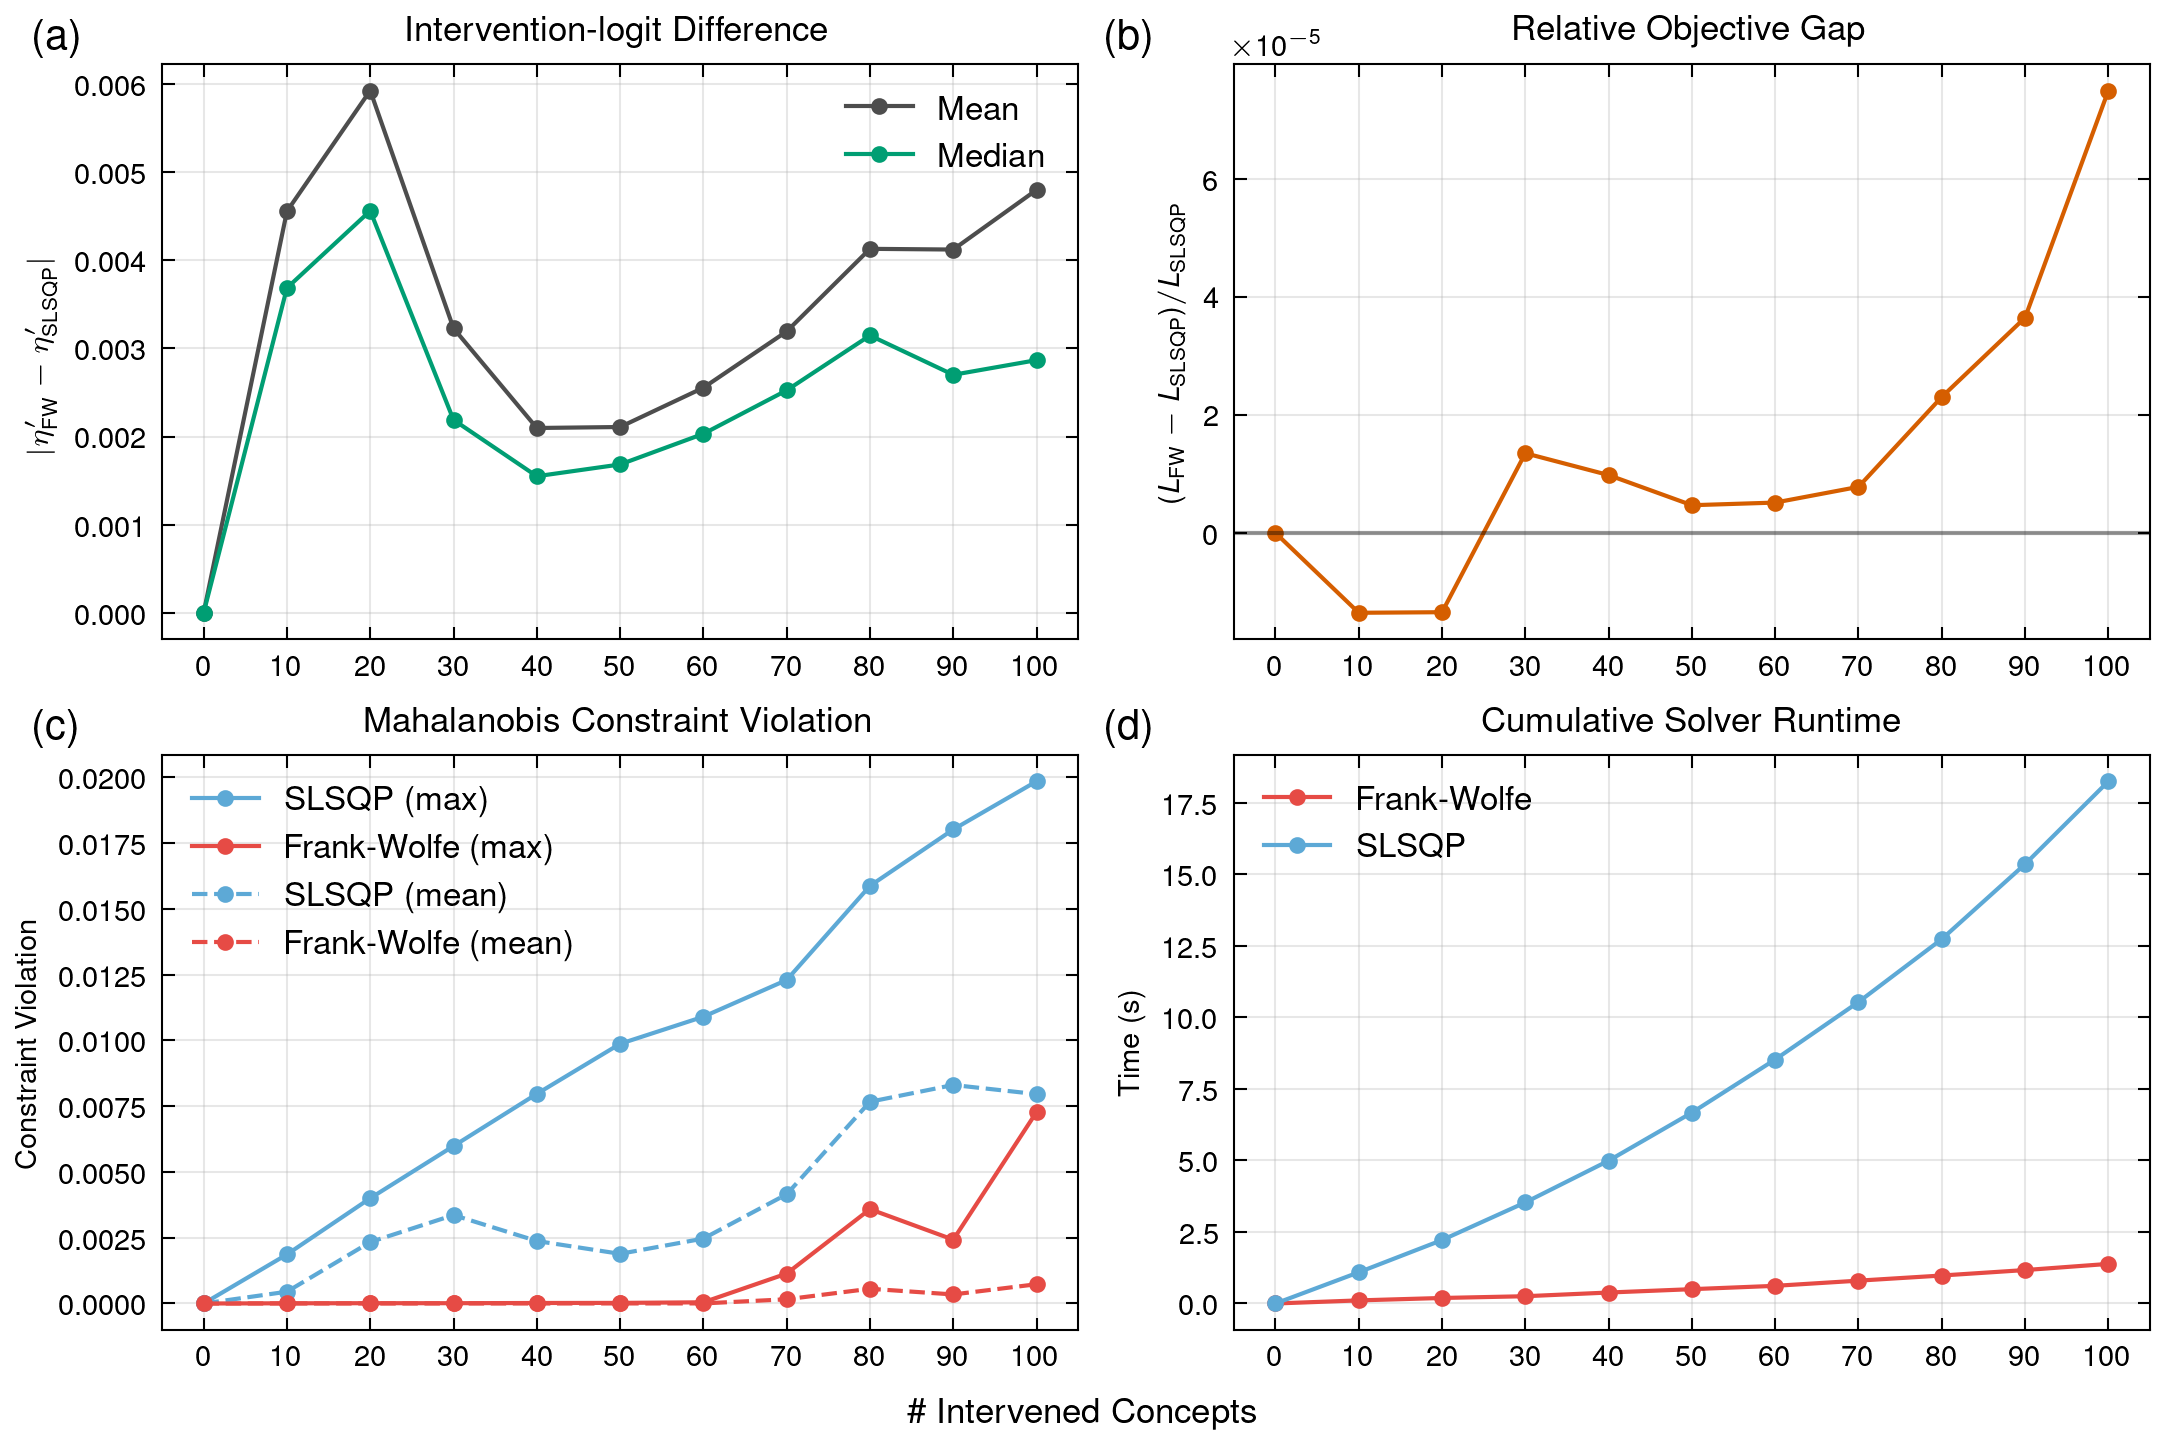

In [3]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(7.2, 4.8),
    constrained_layout=True,
    dpi=300,
)

ax_logit = axes[0, 0]
ax_obj = axes[0, 1]
ax_violation = axes[1, 0]
ax_time = axes[1, 1]

x = diff["num_intervened"]

def add_panel_label(ax, label):
    ax.text(
        -0.14, 1.08, label,
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        ha="left",
    )

def style_axis(ax):
    ax.grid(alpha=0.3)
    ax.minorticks_off()
    ax.set_xticks(x)
    ax.set_xticklabels(x)

# (a) Logit difference
ax_logit.plot(
    x,
    diff["abs_diff_mean"],
    marker="o",
    label="Mean",
    color="#4D4D4D",
)
ax_logit.plot(
    x,
    diff["abs_diff_median"],
    marker="o",
    label="Median",
    color="#009E73",
)
# ax_logit.plot(
#     x,
#     diff["abs_diff_max"],
#     marker="o",
#     linestyle="--",
#     label="Max",
#     color="#E64B45",
# )
ax_logit.set_title("Intervention-logit Difference")
ax_logit.set_ylabel(r"$|\eta'_{\mathrm{FW}}-\eta'_{\mathrm{SLSQP}}|$")
ax_logit.legend(frameon=False, fontsize=8)
style_axis(ax_logit)
add_panel_label(ax_logit, "(a)")

# (b) Relative objective gap
obj_gap = diff["fw_objective_mean"] - diff["slsqp_objective_mean"]
rel_obj_gap = obj_gap / diff["slsqp_objective_mean"].abs().clip(lower=1e-12)

ax_obj.plot(
    x,
    rel_obj_gap,
    marker="o",
    color="#D55E00",
)
ax_obj.axhline(0, color="black", linewidth=1, alpha=0.4)
ax_obj.set_title("Relative Objective Gap")
ax_obj.set_ylabel(r"$(L_{\mathrm{FW}}-L_{\mathrm{SLSQP}})/L_{\mathrm{SLSQP}}$")
style_axis(ax_obj)
add_panel_label(ax_obj, "(b)")


# (c) Mahalanobis constraint violation
ax_violation.plot(
    x,
    diff["slsqp_maha_violation_max"],
    marker="o",
    label="SLSQP (max)",
    color="#5DA9D6",
)
ax_violation.plot(
    x,
    diff["fw_maha_violation_max"],
    marker="o",
    label="Frank-Wolfe (max)",
    color="#E64B45",
)
ax_violation.plot(
    x,
    diff["slsqp_maha_violation_mean"],
    marker="o",
    linestyle="--",
    label="SLSQP (mean)",
    color="#5DA9D6",
)
ax_violation.plot(
    x,
    diff["fw_maha_violation_mean"],
    marker="o",
    linestyle="--",
    label="Frank-Wolfe (mean)",
    color="#E64B45",
)
ax_violation.set_title("Mahalanobis Constraint Violation")
ax_violation.set_ylabel("Constraint Violation")
ax_violation.legend(frameon=False, fontsize=8)
style_axis(ax_violation)
add_panel_label(ax_violation, "(c)")


# (d) Runtime
ax_time.plot(
    timing["num_intervened"],
    timing["fw_cumulative_sec"],
    marker="o",
    label="Frank-Wolfe",
    color="#E64B45",
)
ax_time.plot(
    timing["num_intervened"],
    timing["slsqp_cumulative_sec"],
    marker="o",
    label="SLSQP",
    color="#5DA9D6",
)
ax_time.set_title("Cumulative Solver Runtime")
ax_time.set_ylabel("Time (s)")
ax_time.legend(frameon=False, fontsize=8)
style_axis(ax_time)
add_panel_label(ax_time, "(d)")


fig.supxlabel(r"\# Intervened Concepts")

# fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

# print(f"Saved figure to: {output_path}")

In [4]:
summary = {
    "final_num_intervened": int(timing["num_intervened"].iloc[-1]),
    "final_fw_sec": timing["fw_cumulative_sec"].iloc[-1],
    "final_slsqp_sec": timing["slsqp_cumulative_sec"].iloc[-1],
    "speedup": timing["slsqp_cumulative_sec"].iloc[-1] / timing["fw_cumulative_sec"].iloc[-1],
    "final_abs_diff_mean": diff["abs_diff_mean"].iloc[-1],
    "final_abs_diff_max": diff["abs_diff_max"].iloc[-1],
}
pd.Series(summary)

final_num_intervened    100.000000
final_fw_sec              1.383558
final_slsqp_sec          18.247826
speedup                  13.189060
final_abs_diff_mean       0.004798
final_abs_diff_max        0.159459
dtype: float64